In [1]:
import os

os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import mediapy as media
import numpy as np
from tqdm import tqdm

In [2]:
from scipy.spatial.transform import Rotation as R
from g2scene import Scene, GRASPNET_SCENE_ROOT, MODEL_DIR, HAND_ASSETS

object_id = 5

XML_PATH = f'scene_{object_id}_0000.xml'

s = Scene(scene_dir=GRASPNET_SCENE_ROOT, model_dir=MODEL_DIR, hand_assets=HAND_ASSETS)

s.save_xml(XML_PATH, obj_indexes=object_id)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Saved → scene_5_0000.xml


In [3]:
model = mujoco.MjModel.from_xml_path(XML_PATH)
data  = mujoco.MjData(model)
mujoco.mj_forward(model, data)

In [4]:
FPS      = 30
N_FRAMES = 120  # one full circle

renderer = mujoco.Renderer(model, height=720, width=1280)

cam           = mujoco.MjvCamera()
cam.lookat[:] = [0.0, 0.0, 0.1]
cam.elevation = -30
cam.distance  = 1.5

frames = []
for azimuth in tqdm(np.linspace(0, 360, N_FRAMES, endpoint=False), desc="Rendering frames"):
    cam.azimuth = azimuth
    renderer.update_scene(data, camera=cam)
    frames.append(renderer.render())

media.show_video(frames, fps=FPS)

Rendering frames: 100%|██████████| 120/120 [00:00<00:00, 344.93it/s]


This browser does not support the video tag.


In [5]:
from graspnetAPI import GraspGroup

GRASP_POSES = "/home/sbehnam/Project/data/scenes/scene_0000/grasp_group_mine.npy"

gg = GraspGroup(np.load(GRASP_POSES))

gg.sort_by_score()

print(f"Loaded {len(gg)} grasps from GraspNet.")

sample_grasp = gg.random_sample(1)[0]

sample_grasp

Loaded 82065 grasps from GraspNet.


Grasp: score:0.800000011920929, width:0.12050469219684601, height:0.019999999552965164, depth:0.019999999552965164, translation:[-0.05264985  0.01208367  0.44045177]
rotation:
[[-0.62393171  0.73191249  0.27388567]
 [ 0.36492357 -0.03703801  0.93030047]
 [ 0.69104272  0.68039125 -0.24398293]]
object id:15

In [6]:
interested_gg = [g for g in gg if g.object_id == object_id]

print(f"Found {len(interested_gg)} grasps for object ID {object_id}.")

Found 14106 grasps for object ID 5.


----

In [ ]:
import numpy as np
import os
from tqdm import tqdm

from graspnetAPI.utils.xmlhandler import xmlReader
from graspnetAPI.utils.utils import get_obj_pose_list, generate_views, get_model_grasps, transform_points
from graspnetAPI.utils.rotation import batch_viewpoint_params_to_matrix

In [8]:
CAMERA_POSES = '/home/sbehnam/Project/data/scenes/scene_0000/kinect/camera_poses.npy'
CAMERA_2_TABLE = '/home/sbehnam/Project/data/scenes/scene_0000/kinect/cam0_wrt_table.npy'

COLLISION_LABEL_PATH = '/home/sbehnam/Project/data/scenes/scene_0000/collision_labels.npz'
GRASP_LABEL_PATH     = '/home/sbehnam/Project/data/scenes/scene_0000/grasp_labels/'
FIRST_ANNOTATION_XML = '/home/sbehnam/Project/data/scenes/scene_0000/kinect/annotations/0000.xml'

In [9]:
def loadCollisionLabel(collision_label_path):
    print("Loading collision labels ...")
    collision_label = np.load(collision_label_path)
    collisionLabel = []
    for j in range(len(collision_label)):
        collisionLabel.append(collision_label['arr_{}'.format(j)])
    return collisionLabel

def load_grasp_label(grasp_label_path, object_ids):
    graspLabels = {}    
    for i in tqdm(object_ids, desc="Loading grasp labels ..."):
        file = np.load(
            os.path.join(
                grasp_label_path,
                '{}_labels.npz'.format(str(i).zfill(3))
            )
        )
        graspLabels[i] = (
            file['points'].astype(np.float32),
            file['offsets'].astype(np.float32),
            file['scores'].astype(np.float32)
        )
    return graspLabels

def cam_pose(camera_poses_path, camera_2_table_path):
    camera_poses = np.load(camera_poses_path)
    align_mat    = np.load(camera_2_table_path)
    return align_mat @ camera_poses[0]  # Always use the first camera pose !!!

def pose2vectors(annotation_xml_path):
    xml_reader  = xmlReader(annotation_xml_path)
    return xml_reader.getposevectorlist()

In [10]:
from graspnetAPI import GraspGroup

TOTAL_SCENE_NUM = 190
GRASP_HEIGHT = 0.02
FRICTION_COEF_THRESH = 0.4

In [11]:
camera_pose = np.load(CAMERA_POSES)[0]
pose_vectors = pose2vectors(FIRST_ANNOTATION_XML)

obj_list, pose_list = get_obj_pose_list(camera_pose, pose_vectors)

grasp_labels = load_grasp_label(GRASP_LABEL_PATH, obj_list)
collision_dump = loadCollisionLabel(COLLISION_LABEL_PATH)

Loading grasp labels ...: 100%|██████████| 9/9 [00:03<00:00,  2.49it/s]

Loading collision labels ...


In [12]:
num_views, num_angles, num_depths = 300, 12, 4
template_views = generate_views(num_views)
template_views = template_views[np.newaxis, :, np.newaxis, np.newaxis, :]
template_views = np.tile(template_views, [1, 1, num_angles, num_depths, 1])

In [13]:
grasp_group = GraspGroup()
for i, (obj_idx, trans) in enumerate(zip(obj_list, pose_list)):
    sampled_points, offsets, fric_coefs = grasp_labels[obj_idx]
    collision = collision_dump[i]
    point_inds = np.arange(sampled_points.shape[0])

    num_points = len(point_inds)
    target_points = sampled_points[:, np.newaxis, np.newaxis, np.newaxis, :]
    target_points = np.tile(target_points, [1, num_views, num_angles, num_depths, 1])
    views = np.tile(template_views, [num_points, 1, 1, 1, 1])
    angles = offsets[:, :, :, :, 0]
    depths = offsets[:, :, :, :, 1]
    widths = offsets[:, :, :, :, 2]

    mask1 = ((fric_coefs <= FRICTION_COEF_THRESH) & (fric_coefs > 0) & ~collision)
    target_points = target_points[mask1]
    target_points = transform_points(target_points, trans)
    target_points = transform_points(target_points, np.linalg.inv(camera_pose))
    views = views[mask1]
    angles = angles[mask1]
    depths = depths[mask1]
    widths = widths[mask1]
    fric_coefs = fric_coefs[mask1]

    Rs = batch_viewpoint_params_to_matrix(-views, angles)
    Rs = np.matmul(trans[np.newaxis, :3, :3], Rs)
    Rs = np.matmul(np.linalg.inv(camera_pose)[np.newaxis,:3,:3], Rs)

    num_grasp = widths.shape[0]
    scores = (1.1 - fric_coefs).reshape(-1,1)
    widths = widths.reshape(-1,1)
    heights = GRASP_HEIGHT * np.ones((num_grasp,1))
    depths = depths.reshape(-1,1)
    rotations = Rs.reshape((-1,9))
    object_ids = obj_idx * np.ones((num_grasp,1), dtype=np.int32)

    obj_grasp_array = np.hstack([scores, widths, heights, depths, rotations, target_points, object_ids]).astype(np.float32)

    grasp_group.grasp_group_array = np.concatenate((grasp_group.grasp_group_array, obj_grasp_array))

In [14]:
SAVE_PATH = os.path.join('/home/sbehnam/Project/data/scenes/scene_0000', 'grasp_group_mine')
grasp_group.save_npy(SAVE_PATH)

In [15]:
len(grasp_group)

82065

In [16]:
from graspnetAPI import GraspNet

g_net = GraspNet(root='/home/sbehnam/Project/data/', camera='kinect', split='custom', sceneIds=[0])

Loading data path...: 100%|██████████| 1/1 [00:00<00:00, 103.67it/s]


In [17]:
cloud = g_net.loadScenePointCloud(sceneId=0, camera='kinect', annId=0, align=False)

In [18]:
from graspnetAPI.utils.utils import parse_posevector
import open3d as o3d

def loadSceneModel(annId = 0, align = False):
    '''
    **Input:**

     - sceneId: int of the scene index.
    
    - camera: string of type of camera, 'realsense' or 'kinect'

     - annId: int of the annotation index.

     - align: bool of whether align to the table frame.

     **Output:**

     - open3d.geometry.PointCloud list of the scene models.
    '''
    if align:
        camera_poses = np.load(CAMERA_POSES)
        camera_pose = camera_poses[annId]
        align_mat = np.load(CAMERA_2_TABLE)
        camera_pose = np.matmul(align_mat,camera_pose)
    scene_reader = xmlReader(FIRST_ANNOTATION_XML)
    posevectors = scene_reader.getposevectorlist()
    obj_list = []
    mat_list = []
    model_list = []
    pose_list = []
    for posevector in posevectors:
        obj_idx, pose = parse_posevector(posevector)
        obj_list.append(obj_idx)
        mat_list.append(pose)

    for obj_idx, pose in zip(obj_list, mat_list):
       plyfile = os.path.join('/home/sbehnam/models', '%03d'%obj_idx, 'nontextured.ply')
       model = o3d.io.read_point_cloud(plyfile)
       points = np.array(model.points)
       if align:
           pose = np.dot(camera_pose, pose)
       points = transform_points(points, pose)
       model.points = o3d.utility.Vector3dVector(points)
       model_list.append(model)
       pose_list.append(pose)

    return model_list

In [19]:
object_pcd = loadSceneModel(annId=0, align=False)

In [20]:
geometries = []
geometries.append(cloud)
interested_gg = grasp_group[grasp_group.grasp_group_array[:, -1] == 5]

sampled_grasp = interested_gg.random_sample(numGrasp=4)

geometries += sampled_grasp.to_open3d_geometry_list()

# write it into .ply
# combined = o3d.geometry.PointCloud()

# for geom in geometries:
#     if isinstance(geom, o3d.geometry.PointCloud):
#         combined += geom
#     elif isinstance(geom, o3d.geometry.TriangleMesh):
#         combined += geom.sample_points_uniformly(number_of_points=1000)

# o3d.io.write_point_cloud('debug_combined_5.ply', combined)

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x6074ac46ff20 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


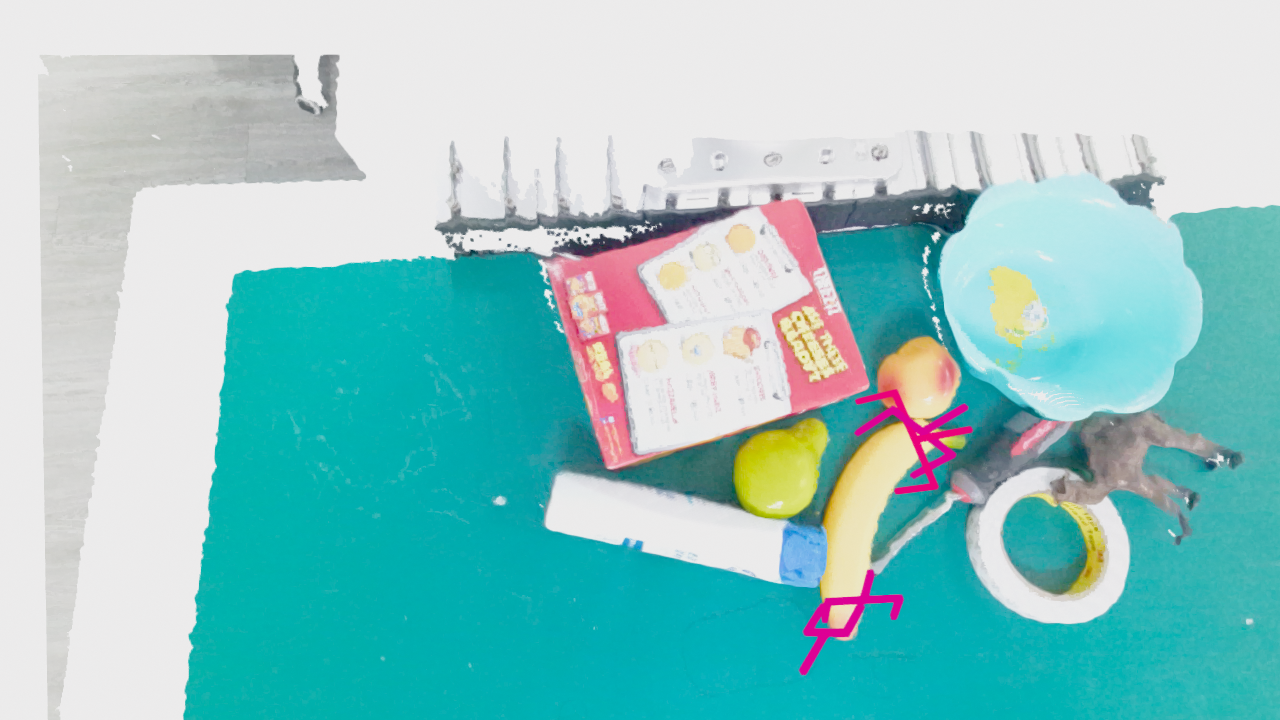

In [21]:
import numpy as np
import open3d as o3d

def render_geometries_to_notebook(geometries, width=1280, height=720, shift_x=-0.2):
    renderer = o3d.visualization.rendering.OffscreenRenderer(width, height)
    renderer.scene.set_background([1, 1, 1, 1])
    
    mat = o3d.visualization.rendering.MaterialRecord()
    mat.shader = "defaultUnlit"
    
    for i, g in enumerate(geometries):
        renderer.scene.add_geometry(f"geom_{i}", g, mat)
    
    bounds = o3d.geometry.AxisAlignedBoundingBox()
    for g in geometries:
        bounds += g.get_axis_aligned_bounding_box()
    
    center = bounds.get_center()
    extent = bounds.get_extent()
    look_at = center + np.array([extent[0] * shift_x, 0, 0])
    eye = look_at + np.array([0, 0, -np.linalg.norm(extent) * 0.35])
    up = np.array([0, 1, 0])
    
    renderer.setup_camera(60.0, look_at.astype(np.float32),
                          eye.astype(np.float32), up.astype(np.float32))
    
    img = renderer.render_to_image()
    o3d.io.write_image("scene.png", img)
    
    from IPython.display import Image
    return Image("scene.png")

render_geometries_to_notebook(geometries)

In [ ]:
sampled_grasp[0]

Grasp: score:0.7000000476837158, width:0.07723478972911835, height:0.019999999552965164, depth:0.009999999776482582, translation:[-0.12182258  0.0191296   0.4786962 ]
rotation:
[[ 0.22006011  0.47901127 -0.84977746]
 [ 0.01666055  0.8691594   0.49425119]
 [ 0.975344   -0.12292271  0.18328674]]
object id:5

In [22]:
sampled_grasp.save_npy('/home/sbehnam/Project/data/scenes/scene_0000/some_banana_grasp')